In [36]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile
from google.colab import files

In [21]:
tf.random.set_seed(42)
tf.__version__

'2.19.0'

In [22]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [23]:
with zipfile.ZipFile('face-mask-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [24]:
base_dir='data'
print('DataSet Folders',os.listdir(base_dir))

DataSet Folders ['with_mask', 'without_mask']


In [25]:
datagen=ImageDataGenerator(rescale=1./255,validation_split=0.2)

train_data=datagen.flow_from_directory(base_dir,
                                       target_size=(224,224),
                                       batch_size=32,
                                       class_mode='binary',
                                       subset='training')

Found 6043 images belonging to 2 classes.


In [26]:
test_data=datagen.flow_from_directory(base_dir,
                                       target_size=(224,224),
                                       batch_size=32,
                                       class_mode='binary',
                                       subset='validation')

Found 1510 images belonging to 2 classes.


In [27]:
# creating CNN model
model=tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16,3,activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(16,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

In [28]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 220, 220, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 110, 110, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 108, 108, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 106, 106, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 53, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 51, 51, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,560,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,281 (9.90 MB)

 Trainable params: 2,595,281 (9.90 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history=model.fit(train_data,
                  validation_data=test_data,
                  epochs=5)

Epoch 1/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 682s 4s/step - accuracy: 0.7412 - loss: 0.5031 - val_accuracy: 0.8901 - val_loss: 0.2681
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 680s 4s/step - accuracy: 0.8968 - loss: 0.2521 - val_accuracy: 0.9305 - val_loss: 0.2383
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 716s 4s/step - accuracy: 0.9047 - loss: 0.2296 - val_accuracy: 0.9325 - val_loss: 0.2073
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 670s 4s/step - accuracy: 0.9359 - loss: 0.1788 - val_accuracy: 0.9444 - val_loss: 0.1699
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 674s 4s/step - accuracy: 0.9521 - loss: 0.1331 - val_accuracy: 0.9391 - val_loss: 0.1859


In [31]:
loss,accuracy=model.evaluate(test_data)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 43s 905ms/step - accuracy: 0.9358 - loss: 0.1826
Loss: 0.185870960354805
Accuracy: 0.939072847366333


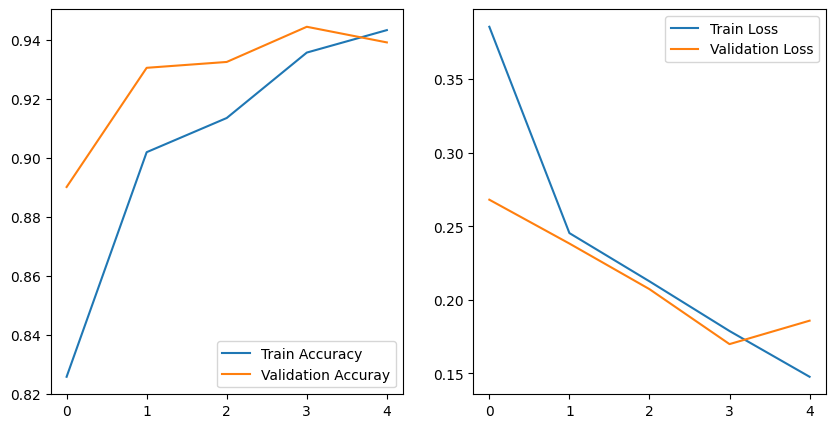

In [32]:
# plot accuracy and loss
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuray')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


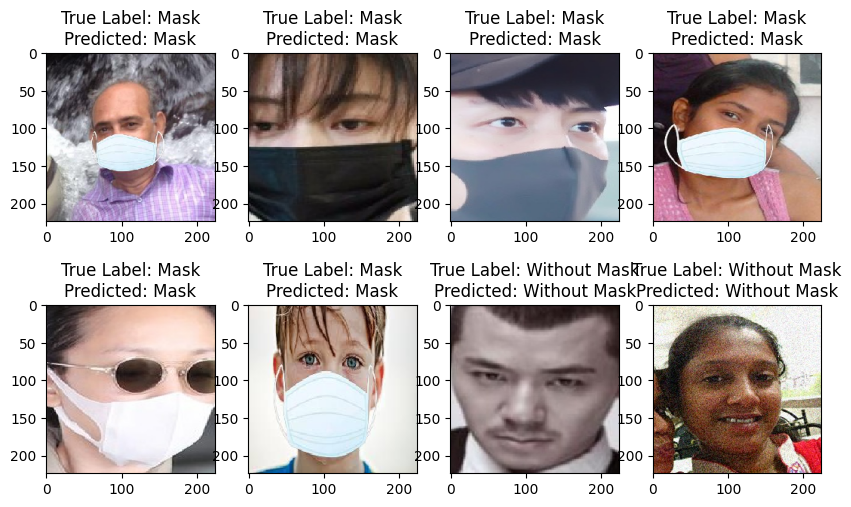

In [33]:
image,labels=next(test_data)
predictions=model.predict(image)
plt.figure(figsize=(10,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(image[i])
    true_label=labels[i]
    if true_label==0:
        true_label='Mask'
    else:
        true_label='Without Mask'
    predicted_label='Without Mask' if predictions[i]>0.5 else 'Mask'
    plt.title(f'True Label: {true_label}\nPredicted: {predicted_label}')

plt.show()


Saving WhatsApp Image 2025-08-17 at 12.59.01.jpeg to WhatsApp Image 2025-08-17 at 12.59.01.jpeg
File Uploaded Successfully WhatsApp Image 2025-08-17 at 12.59.01.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Prediction: Without Mask
Confidence: 99.9966 %


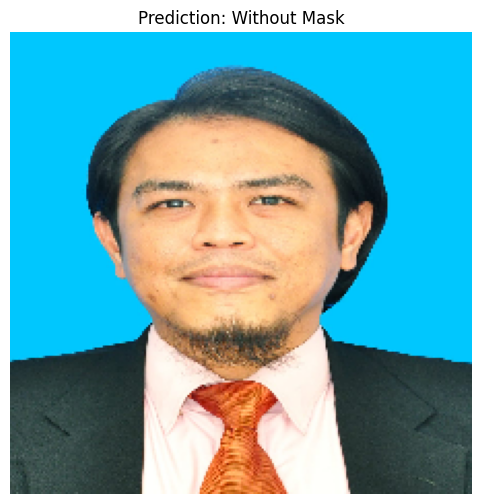

In [38]:
from google.colab import files
uploaded=files.upload()
for fn in uploaded.keys():
    img_path=fn
    print('File Uploaded Successfully',img_path)

    img=image.load_img(img_path,target_size=(224,224))
    img_array=image.img_to_array(img)
    img_array=np.expand_dims(img_array,axis=0)/255.0


    pred=model.predict(img_array)[0][0]
    label='Without Mask'if pred>0.5 else 'Mask'
    print(f'Prediction: {label}')
    print('Confidence:',100*(1-pred) if pred<0.5 else 100*pred,'%')

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(f'Prediction: {label}')
    plt.axis('off')
    plt.show()

In [39]:
model.save('CNN_face_mask.keras')
print('Model Saved')

Model Saved
